# [LAB 05] XGBoost Channel 분류 (Region + 6개 매출)
## 구매 패턴 기반 고객 군집 노트북과 동일 전처리 → Channel(1/2) 예측

- **전처리**: 구매액 6개 np.log1p → StandardScaler, Region은 **범주형 원핫**(Region_2, Region_3), 학습 피처 **8개**(log 6 + Region 더미 2)
- **타겟**: Channel (1 또는 2) → 라벨 0/1로 변환하여 이진 분류
- **모델**: XGBoost 분류기
- **저장**: scaler, XGB 모델 각각 pkl 저장
- **해석**: Feature Importance, SHAP 분석 포함


## 1. 라이브러리 및 데이터 로드


In [1]:
from hossam import load_data
import pandas as pd
import numpy as np
from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
import pickle
from pathlib import Path

my_dpi = 200
RAW_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
LAB05_DIR = Path('.').resolve()


c:\Users\bohee\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.4.8


In [2]:
origin = load_data('wholesale_customers')
df = origin[RAW_COLS + ['Region', 'Channel']].copy()
df.head(10)


이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,Channel
0,12669,9656,7561,214,2674,1338,3,2
1,7057,9810,9568,1762,3293,1776,3,2
2,6353,8808,7684,2405,3516,7844,3,2
3,13265,1196,4221,6404,507,1788,3,1
4,22615,5410,7198,3915,1777,5185,3,2
5,9413,8259,5126,666,1795,1451,3,2
6,12126,3199,6975,480,3140,545,3,2
7,7579,4956,9426,1669,3321,2566,3,2
8,5963,3648,6192,425,1716,750,3,1
9,6006,11093,18881,1159,7425,2098,3,2


## 2. 전처리


In [3]:
df_log = df[RAW_COLS].copy()
for c in RAW_COLS:
    df_log[f'log_{c}'] = np.log1p(df_log[c])
# Region: 범주형(1,2,3) → 원핫 인코딩 (drop_first=True → Region_2, Region_3)
region_dummies = pd.get_dummies(df['Region'], prefix='Region', drop_first=True)
df_log = pd.concat([df_log, region_dummies], axis=1)

scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)
log_cols = [f'log_{c}' for c in RAW_COLS]
FEATURE_COLS = log_cols + list(region_dummies.columns)  # 학습 피처 8개: log 6 + Region 더미 2개
X = sdf[FEATURE_COLS].values
y = (df['Channel'] - 1).values

print('X shape:', X.shape)
print('y unique:', np.unique(y))
X[:3]


X shape: (440, 8)
y unique: [0 1]


array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595, -0.34582203,  0.62642243],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606, -0.34582203,  0.62642243],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339, -0.34582203,  0.62642243]])

## 2.5 성능평가 함수 (LAB 09 공통)


In [4]:
def hs_cls_bin_scores(estimator, x_test, y_test):
    y_pred_proba = estimator.predict_proba(x_test)
    y_pred_proba_1 = y_pred_proba[:, 1]
    y_pred = estimator.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm
    classname = getattr(estimator, '__class__', type(estimator)).__name__
    auc = roc_auc_score(y_test, y_pred_proba_1)
    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred, zero_division=0)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred, zero_division=0)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP) if (TN + FP) > 0 else 0],
        "특이성(TNR)": [1 - (FP / (TN + FP)) if (TN + FP) > 0 else 0],
        "F1-Score": [f1_score(y_test, y_pred, zero_division=0)],
        "AUC": [auc]
    }, index=[classname])
    roc_fpr, roc_tpr, _ = roc_curve(y_test, y_pred_proba_1)
    fig, ax = plt.subplots(1, 1, figsize=(1000/my_dpi, 900/my_dpi), dpi=my_dpi)
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    plt.close()
    return score_df


In [5]:
def hs_learning_cv(estimator, x, y, scoring=None, cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1):
    is_classification = getattr(estimator, '_estimator_type', None) == 'classifier'
    if scoring is None:
        scoring = 'roc_auc' if is_classification else 'neg_root_mean_squared_error'
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=estimator, X=x, y=y, train_sizes=train_sizes, cv=cv, scoring=scoring,
        n_jobs=n_jobs, shuffle=False, random_state=52,
    )
    classname = getattr(estimator, '__class__', type(estimator)).__name__
    if not is_classification:
        train_mean, cv_mean = -train_scores.mean(axis=1), -cv_scores.mean(axis=1)
        cv_std = cv_scores.std(axis=1)
        metric_name = 'RMSE'
    else:
        train_mean, cv_mean = train_scores.mean(axis=1), cv_scores.mean(axis=1)
        cv_std = cv_scores.std(axis=1)
        metric_name = scoring.upper()
    gap_ratio = train_mean[-1] - cv_mean[-1] if is_classification else train_mean[-1] / cv_mean[-1]
    var_ratio = cv_std[-1]
    if is_classification:
        if train_mean[-1] < 0.6 and cv_mean[-1] < 0.6: status = "⚠ 과소적합"
        elif gap_ratio > 0.1: status = "⚠ 과대적합"
        elif gap_ratio <= 0.05 and var_ratio <= 0.05: status = "✅ 일반화 양호"
        elif var_ratio > 0.1: status = "⚠ 데이터 부족"
        else: status = "⚠ 판단유보"
    else:
        status = "✅ 일반화 양호" if 0.95 <= gap_ratio and var_ratio <= 0.10 else "⚠ 판단유보"
    result_df = DataFrame({
        f"Train {metric_name}": [train_mean[-1]],
        f"CV {metric_name} 평균": [cv_mean[-1]],
        f"CV {metric_name} 표준편차": [cv_std[-1]],
        "Train/CV 비율": [gap_ratio],
        "CV 변동성 비율": [var_ratio],
        "판정 결과": [status],
    }, index=[classname])
    fig, ax = plt.subplots(1, 1, figsize=(1280/my_dpi, 720/my_dpi), dpi=my_dpi)
    sb.lineplot(x=train_sizes, y=train_mean, marker="o", markeredgecolor="#ffffff", label=f"Train {metric_name}")
    sb.lineplot(x=train_sizes, y=cv_mean, marker="o", markeredgecolor="#ffffff", label=f"CV {metric_name}")
    ax.set_xlabel("학습 데이터 크기", fontsize=8)
    ax.set_ylabel(metric_name, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()
    return result_df


## 3. train/test split 및 XGBoost 학습


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52, stratify=y
)

clf = xgb.XGBClassifier(random_state=52, use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
y_pred_proba_1 = y_pred_proba[:, 1]


c:\Users\bohee\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:37:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. 성능 지표: Accuracy, Confusion Matrix, ROC-AUC


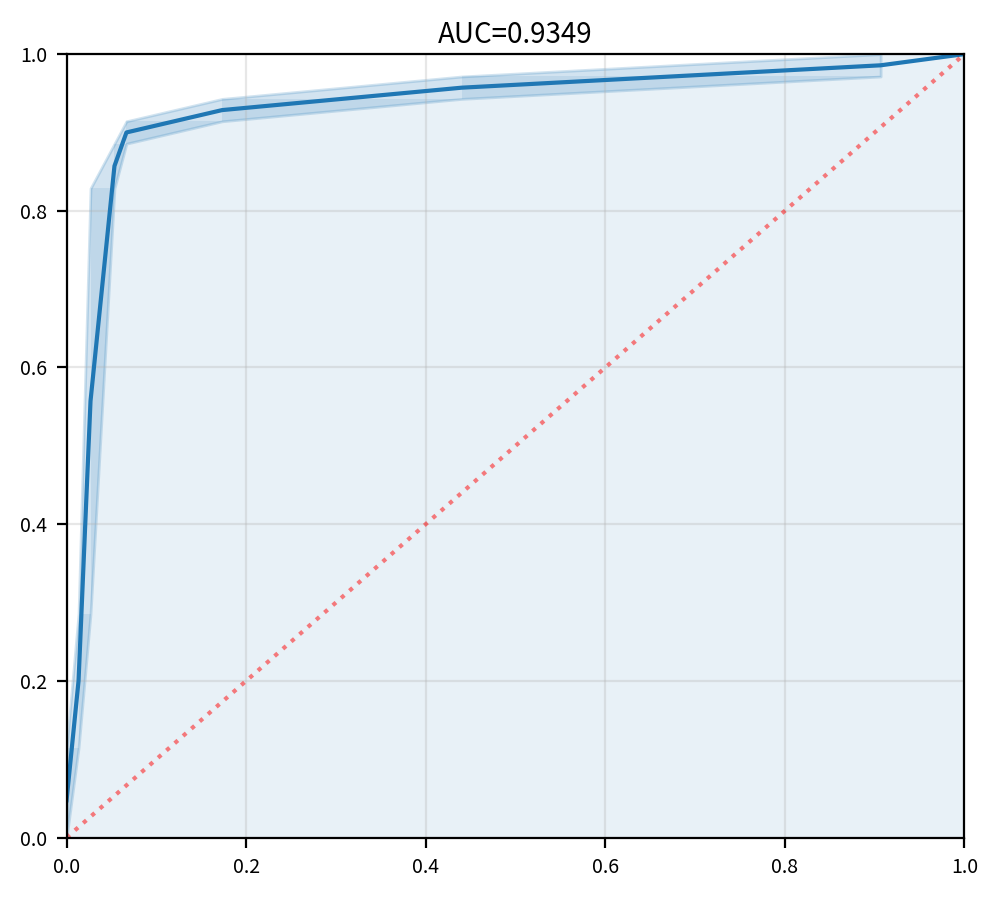

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
XGBClassifier,0.890909,0.925926,0.714286,0.026667,0.973333,0.806452,0.934857


In [7]:
score_df = hs_cls_bin_scores(clf, X_test, y_test)
score_df


In [ ]:
# 혼동행렬 시각화
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cmdf = DataFrame(
    cm,
    index=['Actual 0 (Channel 1)', 'Actual 1 (Channel 2)'],
    columns=['Pred 0', 'Pred 1']
)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=my_dpi)
sb.heatmap(cmdf, annot=True, fmt='d', linewidths=0.5, cmap='PuOr')
ax.set_title('Confusion Matrix (Channel 예측)')
plt.tight_layout()
plt.show()
plt.close()
cmdf

### ROC 곡선 직접 그리기 (FPR, TPR, 임계점)

- **X축**: FPR (False Positive Rate, 위양성률) = FP / (FP + TN)
- **Y축**: TPR (True Positive Rate, 재현율/민감도) = TP / (TP + FN)
- **임계점(threshold)**: 곡선 위 각 점은 예측 확률을 양성(1)으로 판단하는 기준값 하나에 대응합니다.

In [ ]:
# ROC 곡선에 필요한 값: FPR(X), TPR(Y), 임계점(threshold)
y_pred_proba_1 = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_1)
auc_val = roc_auc_score(y_test, y_pred_proba_1)

# 직접 ROC 곡선 그리기: X=FPR, Y=TPR
fig, ax = plt.subplots(1, 1, figsize=(1000/my_dpi, 900/my_dpi), dpi=my_dpi)
ax.plot(fpr, tpr, label=f'ROC (AUC={auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel('FPR (위양성률)', fontsize=10)
ax.set_ylabel('TPR (재현율)', fontsize=10)
ax.set_title('ROC 곡선 (X=FPR, Y=TPR)', fontsize=10, pad=4)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# 참고: 임계점 몇 개만 곡선 위에 표시 (선택)
# for i in [0, len(thresholds)//4, len(thresholds)//2, -2]:
#     ax.annotate(f'{thresholds[i]:.2f}', (fpr[i], tpr[i]), fontsize=8)
# print('임계점 개수:', len(thresholds))

In [ ]:
# ROC 곡선용 DataFrame (태블로 CSV 업로드용)
y_pred_proba_1 = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_1)
auc_val = roc_auc_score(y_test, y_pred_proba_1)

roc_df = DataFrame({
    'order': np.arange(len(fpr)),   # 태블로에서 선 연결 순서
    'FPR': fpr,                     # X축
    'TPR': tpr,                     # Y축
    'threshold': thresholds,
})
roc_df['AUC'] = auc_val   # 참고용

display(roc_df.head(10))
print(f'총 {len(roc_df)}개 점, AUC={auc_val:.4f}')

# CSV 저장 (같은 폴더에)
csv_path = LAB05_DIR / 'roc_curve_for_tableau.csv'
roc_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {csv_path}')

**태블로에서 ROC 곡선 그리기:**  
CSV 연결 후 **선(Line) 차트**로 만들고, **열(Columns)**에 `FPR`, **행(Rows)**에 `TPR`을 넣은 뒤 **세부(Detail)**에 `order`를 드래그하면 점들이 순서대로 선으로 연결됩니다.  
**데이터 정렬:** 선이 꼬이지 않으려면 **세부(Detail)**에 넣은 `order` 필드에 대해 **정렬(Sort)**을 **오름차순**으로 설정하세요. (또는 `threshold` 기준 오름차순도 동일 효과)

### 다중 모델 ROC / 혼동행렬 → 08 노트북에서 통합 제공

다중 모델 ROC 곡선 및 모델별 Confusion Matrix CSV는 **08-전체_모델_비교_과적합_FeatureImportance_SHAP.ipynb**에서 01~07 모델을 종합해 생성합니다. 해당 노트북의 **「2.5 ROC 곡선 및 혼동행렬」** 섹션을 실행하세요.

In [ ]:
# 다중 모델 ROC·혼동행렬 CSV는 08-전체_모델_비교 노트북의 「2.5 ROC 곡선 및 혼동행렬」 섹션에서 실행하세요.

*(위와 동일: 다중 모델 ROC·혼동행렬은 08 노트북에서 실행)*

In [ ]:
# (08 노트북에서 실행)

## 4.6 학습 곡선 및 과적합 판정


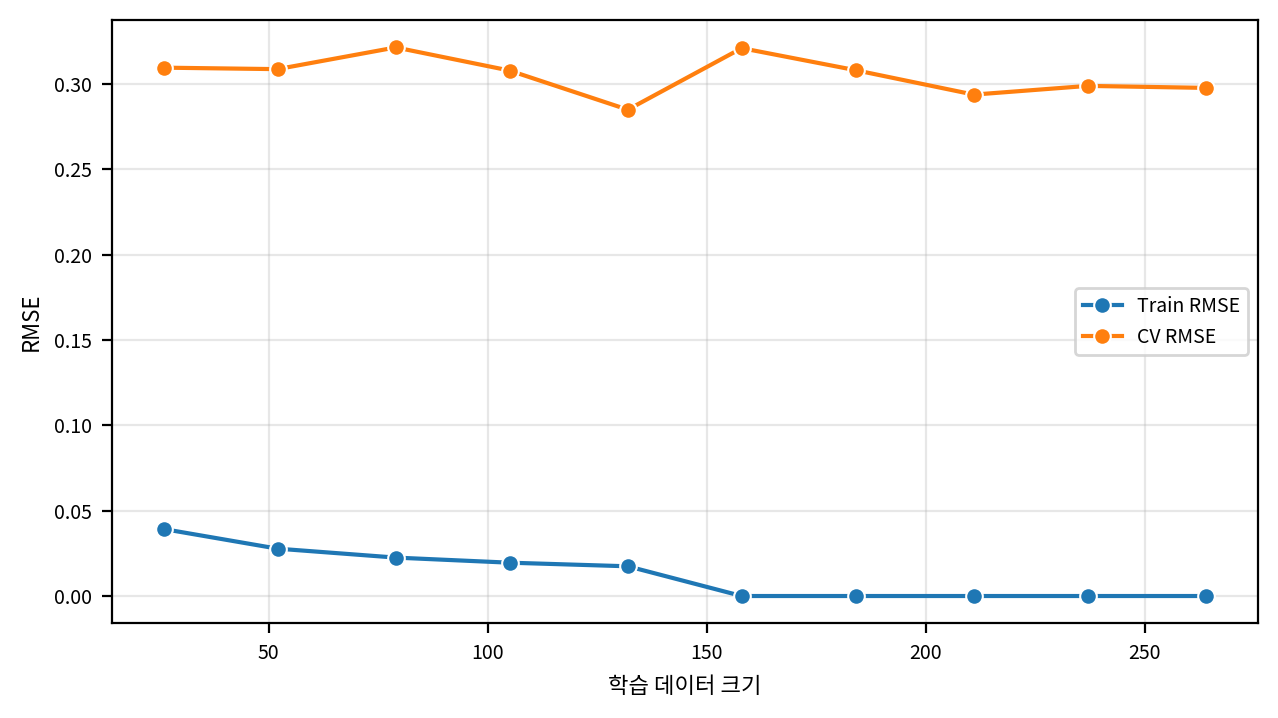

,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
XGBClassifier,-0.0,0.297587,0.048487,-0.0,0.048487,⚠ 판단유보


In [8]:
result_df = hs_learning_cv(clf, X_train, y_train)
result_df


## 4.7 Feature Importance

**총 8개 피처** (스케일된 log 6개 + **Region_2, Region_3**) 기준 중요도입니다.


C:\Users\bohee\AppData\Local\Temp\ipykernel_29428\1317244102.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=imp, x='importance', y='feature', palette='viridis')


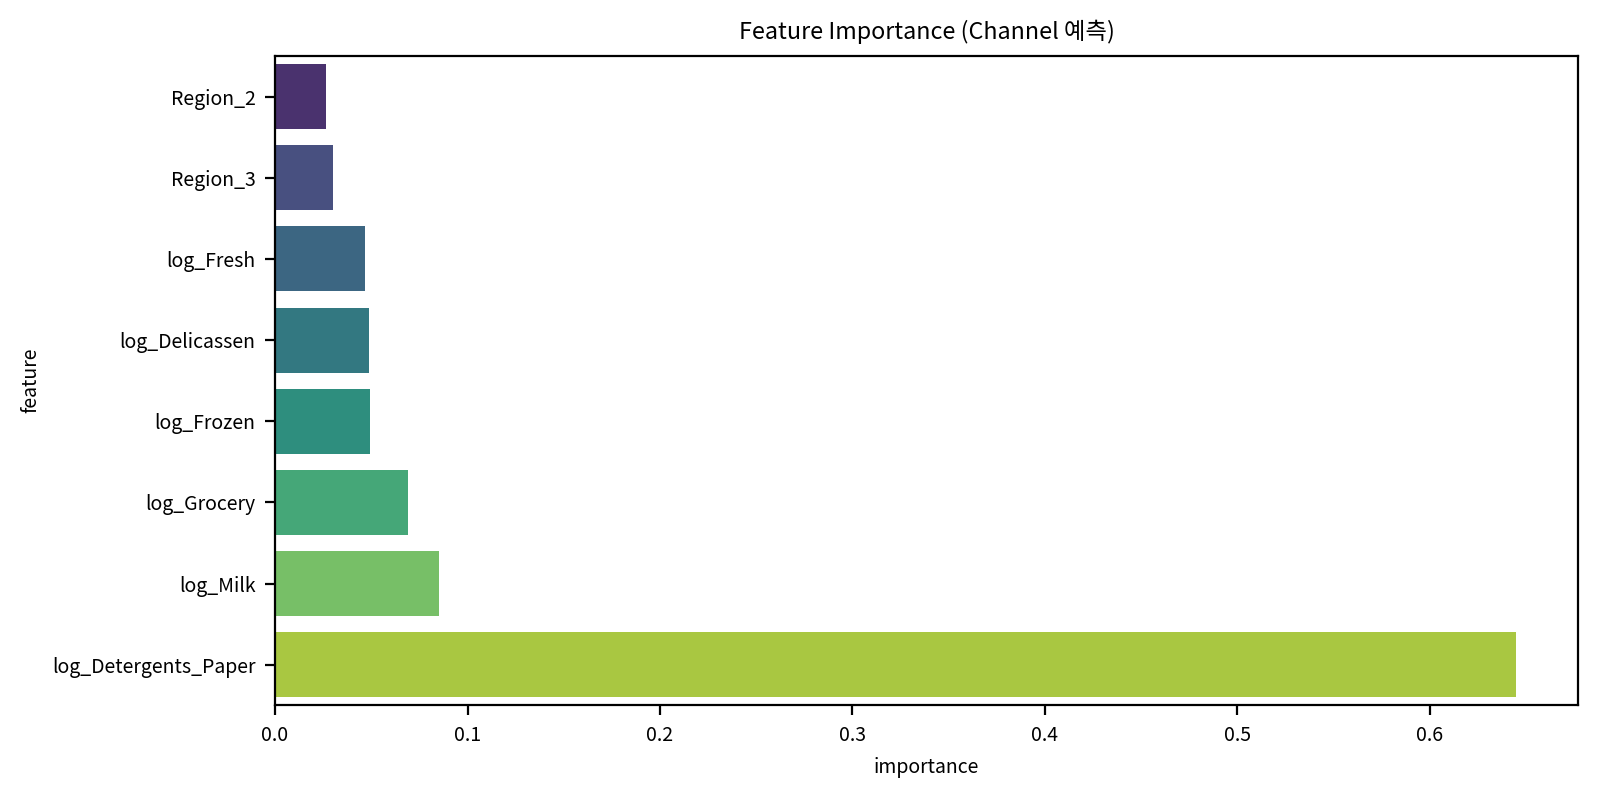

In [9]:
imp = DataFrame({'feature': FEATURE_COLS})
if hasattr(clf, 'feature_importances_'):
    imp['importance'] = clf.feature_importances_
else:
    imp['importance'] = np.abs(clf.coef_[0])
imp = imp.sort_values('importance', ascending=True)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sb.barplot(data=imp, x='importance', y='feature', palette='viridis')
ax.set_title('Feature Importance (Channel 예측)')
plt.tight_layout()
plt.show()
plt.close()


## 5. Scaler / XGB 모델 pkl 저장


In [10]:
scaler_path = LAB05_DIR / 'wholesale_scaler.pkl'
model_path = LAB05_DIR / 'wholesale_xgb.pkl'

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)

print('저장 완료:', scaler_path)
print('저장 완료:', model_path)


저장 완료: C:\Users\bohee\Documents\GitHub\Machine_learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_scaler.pkl
저장 완료: C:\Users\bohee\Documents\GitHub\Machine_learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_xgb.pkl


## 6. SHAP 분석

XGBoost TreeExplainer로 SHAP summary plot 및 영향도 순위를 확인합니다.


In [11]:
import shap

explainer = shap.TreeExplainer(clf, X_train)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP summary (XGBoost)')
plt.tight_layout()
plt.show()
plt.close()


ModuleNotFoundError: No module named 'shap'

In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
idx = np.argsort(mean_abs_shap)[::-1]
ax.barh([FEATURE_COLS[i] for i in idx], mean_abs_shap[idx], color='steelblue', alpha=0.8)
ax.set_xlabel('mean |SHAP value|')
ax.set_title('SHAP 영향도 순위 (XGBoost) — Feature Importance와 비교')
plt.tight_layout()
plt.show()
plt.close()
